In [1]:
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.feature_selection import SelectKBest, f_classif

In [2]:
np.random.seed(42)

df = pd.DataFrame({
    "Age": np.random.randint(18, 30, 20),
    "Study_Hours": np.random.randint(1, 8, 20),
    "Department": np.random.choice(["CSE", "ISE", "ECE"], 20),
    "Grade": np.random.choice(["Poor", "Average", "Good"], 20),
    "Gender": np.random.choice(["Male", "Female"], 20),
    "Marks": np.random.randint(50, 100, 20),
    "Pass": np.random.choice([0, 1], 20)
})

df

,Age,Study_Hours,Department,Grade,Gender,Marks,Pass
0,24,4,ECE,Poor,Female,94,0
1,21,6,ISE,Average,Female,67,0
2,28,6,ISE,Poor,Female,96,0
3,25,2,ECE,Average,Female,73,0
4,22,4,ISE,Good,Female,75,1
5,24,5,ECE,Good,Female,74,0
6,27,1,ECE,Poor,Female,94,0
7,20,4,CSE,Good,Female,90,0
8,24,2,ECE,Good,Male,78,0
9,28,6,CSE,Average,Female,64,0


In [3]:
label_encoder = LabelEncoder()

df["Gender_Label"] = label_encoder.fit_transform(df["Gender"])

df[["Gender", "Gender_Label"]].head()

,Gender,Gender_Label
0,Female,0
1,Female,0
2,Female,0
3,Female,0
4,Female,0


In [4]:
onehot = pd.get_dummies(df, columns=["Department"])

onehot.head()

,Age,Study_Hours,Grade,Gender,Marks,Pass,Gender_Label,Department_CSE,Department_ECE,Department_ISE
0,24,4,Poor,Female,94,0,0,False,True,False
1,21,6,Average,Female,67,0,0,False,False,True
2,28,6,Poor,Female,96,0,0,False,False,True
3,25,2,Average,Female,73,0,0,False,True,False
4,22,4,Good,Female,75,1,0,False,False,True


In [5]:
ordinal = OrdinalEncoder(categories=[["Poor", "Average", "Good"]])

df["Grade_Ordinal"] = ordinal.fit_transform(df[["Grade"]])

df[["Grade", "Grade_Ordinal"]].head()

,Grade,Grade_Ordinal
0,Poor,0.0
1,Average,1.0
2,Poor,0.0
3,Average,1.0
4,Good,2.0


In [6]:
standard = StandardScaler()

standard_scaled = standard.fit_transform(df[["Age", "Study_Hours", "Marks"]])

standard_df = pd.DataFrame(
    standard_scaled,
    columns=["Age", "Study_Hours", "Marks"]
)

standard_df.head()

,Age,Study_Hours,Marks
0,0.129298,0.170114,1.324725
1,-0.978967,1.304210,-0.477168
2,1.606983,1.304210,1.458199
3,0.498719,-0.963982,-0.076747
4,-0.609545,0.170114,0.056726


In [7]:
minmax = MinMaxScaler()

minmax_scaled = minmax.fit_transform(df[["Age", "Study_Hours", "Marks"]])

minmax_df = pd.DataFrame(
    minmax_scaled,
    columns=["Age", "Study_Hours", "Marks"]
)

minmax_df.head()

,Age,Study_Hours,Marks
0,0.555556,0.500000,0.956522
1,0.222222,0.833333,0.369565
2,1.000000,0.833333,1.000000
3,0.666667,0.166667,0.500000
4,0.333333,0.500000,0.543478


In [8]:
robust = RobustScaler()

robust_scaled = robust.fit_transform(df[["Age", "Study_Hours", "Marks"]])

robust_df = pd.DataFrame(
    robust_scaled,
    columns=["Age", "Study_Hours", "Marks"]
)

robust_df.head()

,Age,Study_Hours,Marks
0,0.000000,0.000000,0.725664
1,-0.923077,0.666667,-0.230088
2,1.230769,0.666667,0.796460
3,0.307692,-0.666667,-0.017699
4,-0.615385,0.000000,0.053097


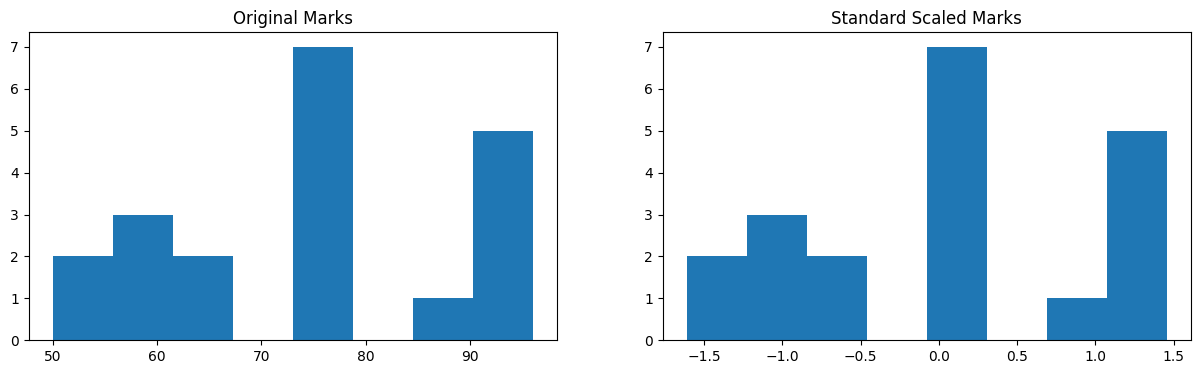

In [9]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.hist(df["Marks"], bins=8)
plt.title("Original Marks")

plt.subplot(1,2,2)
plt.hist(standard_df["Marks"], bins=8)
plt.title("Standard Scaled Marks")

plt.show()

In [10]:
encoded_df = pd.get_dummies(df, drop_first=True)

X = encoded_df.drop("Pass", axis=1)
y = encoded_df["Pass"]

selector = SelectKBest(score_func=f_classif, k=5)

X_new = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
Index(['Age', 'Study_Hours', 'Department_ECE', 'Department_ISE',
       'Gender_Male'],
      dtype='object')


In [11]:
print("Feature Engineering Summary")
print("---------------------------")
print("1. Label Encoding was used for binary categorical data.")
print("2. One-Hot Encoding prevents ordinal relationships.")
print("3. Ordinal Encoding preserves ordered categories.")
print("4. StandardScaler standardizes numerical values.")
print("5. MinMaxScaler scales values between 0 and 1.")
print("6. RobustScaler is resistant to outliers.")
print("7. SelectKBest selected the five most informative features.")

Feature Engineering Summary
---------------------------
1. Label Encoding was used for binary categorical data.
2. One-Hot Encoding prevents ordinal relationships.
3. Ordinal Encoding preserves ordered categories.
4. StandardScaler standardizes numerical values.
5. MinMaxScaler scales values between 0 and 1.
6. RobustScaler is resistant to outliers.
7. SelectKBest selected the five most informative features.


In [12]:
encoded_df.to_csv("feature_engineered_dataset.csv", index=False)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.
